# 3 — What-if / sensitivity: how a climatic system moves temperature & humidity

**Goal.** Support *regulation*: at a given moment, if I change one climatic system (open a vent, run the fog, deploy a shade screen), **how are interior temperature and humidity expected to respond?** — and, inversely, *which settings get me closest to a target T/H?*

**Method.** We reuse the forecasting models from notebook 2, but now treat the actuators as **knobs**: take a real situation, change *one* actuator while holding everything else fixed, and read off the model's predicted temperature/humidity. Averaged over many situations this is a **partial-dependence** (sensitivity) curve.

> ⚠️ **Read this before trusting any number below.** This data is **observational**: nobody ran controlled experiments. The systems were switched on *in response to* the climate (e.g. the shade screen goes out *because* it is hot). So the model sees "screen-on ↔ hot" and may conclude, wrongly, that deploying the screen *warms* the greenhouse. These sensitivities are therefore **associations the model learned, not validated cause-and-effect**. We will *measure* how badly this confounding bites (section 3.3) and frame the control advice accordingly. The honest headline: this notebook is a solid **forecaster** and a **rough advisory**, not a calibrated controller.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from greenhouse_dataset import (
    build_hourly_dataset, add_actuator_history, make_targets, ACTIVE_START,
    CONTINUOUS_COLS, ACTUATOR_COLS, EXTERIOR_COLS, FORECAST_FEATURE_COLS,
)
plt.rcParams["figure.figsize"] = (11, 4)

## 3.1 — Data and per-target models

We rebuild the cleaned active-period dataset (the dead `Radiación_solar_global` sentinel channel is already dropped in the module) and train **one model per (variable, horizon)** — temperature and humidity at **+1 h** and **+6 h** — so we can perturb each cleanly.

In [2]:
df = build_hourly_dataset(root=".")
add_actuator_history(df, windows=(3, 6))
df = df.loc[ACTIVE_START:]

time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "hour", "month"]
FEAT = CONTINUOUS_COLS + ACTUATOR_COLS + EXTERIOR_COLS + FORECAST_FEATURE_COLS + time_feats
TGTS = ["temp_h1", "hum_h1", "temp_h6", "hum_h6"]

targets = make_targets(df, horizons=(1, 6))
data = df[FEAT].join(targets).dropna(subset=FEAT + TGTS)
cut = int(len(data) * 0.8)
train, test = data.iloc[:cut], data.iloc[cut:]

models = {}
for t in TGTS:
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=0)
    m.fit(train[FEAT], train[t])
    models[t] = m
    print(f"{t:8s} test MAE = {mean_absolute_error(test[t], m.predict(test[FEAT])):.2f}")

temp_h1  test MAE = 0.69
hum_h1   test MAE = 2.24
temp_h6  test MAE = 1.14
hum_h6   test MAE = 4.06


These MAEs confirm the models forecast well (units: °C and %). Good forecasting is necessary — but, as we'll see, *not sufficient* for trustworthy what-if control.

## 3.2 — Sensitivity sweeps (partial dependence)

For a chosen actuator we sweep its value from 0 to 60 min/h, holding **all other features at their real test-set values**, and average the model's prediction. The slope of each curve is the model's estimated effect of that system.

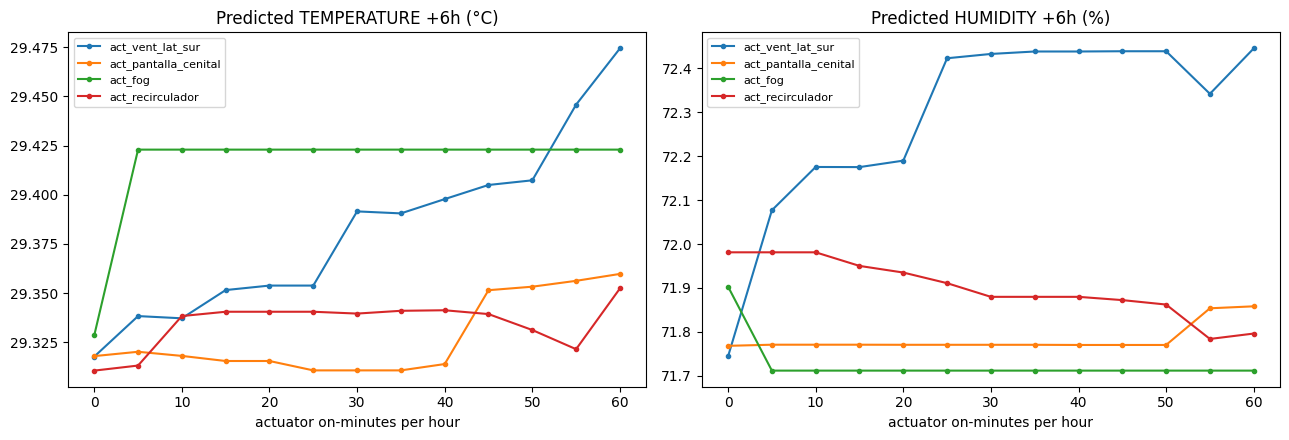

In [3]:
def sweep(actuator, target, values):
    base = test[FEAT]
    preds = []
    for v in values:
        X = base.copy()
        X[actuator] = v
        preds.append(models[target].predict(X).mean())
    return np.array(preds)

sweep_acts = ["act_vent_lat_sur", "act_pantalla_cenital", "act_fog", "act_recirculador"]
vals = np.linspace(0, 60, 13)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for act in sweep_acts:
    axes[0].plot(vals, sweep(act, "temp_h6", vals), "o-", label=act, ms=3)
    axes[1].plot(vals, sweep(act, "hum_h6", vals), "o-", label=act, ms=3)
axes[0].set_title("Predicted TEMPERATURE +6h (°C)")
axes[1].set_title("Predicted HUMIDITY +6h (%)")
for a in axes:
    a.set_xlabel("actuator on-minutes per hour"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What you'll typically see:** nearly **flat, even slightly rising** curves — e.g. deploying the shade screen does *not* visibly cool the greenhouse in the model. Physically a screen and open vents *should* cool. That contradiction is the tell-tale sign of confounding, which we now quantify.

## 3.3 — Why the sweeps look wrong: confounding diagnosis

If a system is switched on **because** the greenhouse is hot, its activity is positively correlated with temperature in the data — so the model cannot separate "the screen is out" from "it is hot". We check the correlation of each actuator with the current interior temperature.

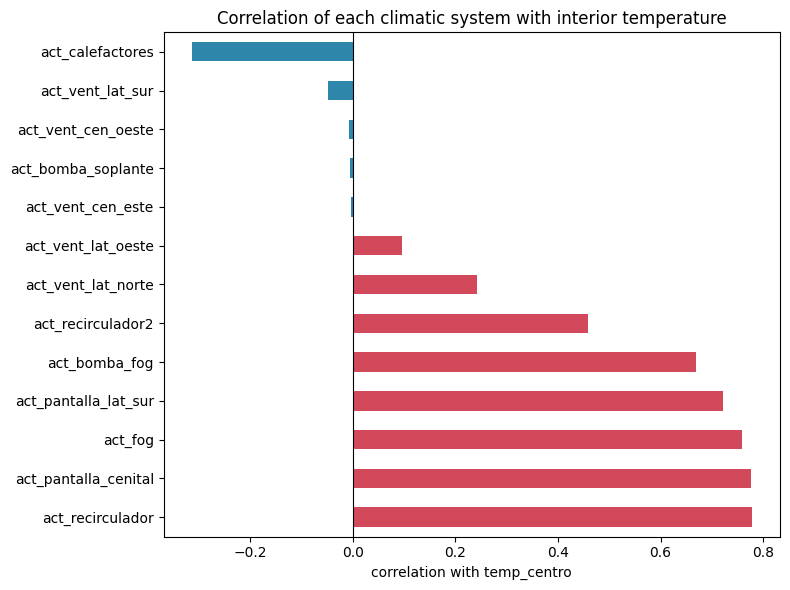

Strongly heat-driven systems (corr > 0.6):
act_recirculador        0.78
act_pantalla_cenital    0.78
act_fog                 0.76
act_pantalla_lat_sur    0.72
act_bomba_fog           0.67


In [4]:
corr = (df[ACTUATOR_COLS].corrwith(df["temp_centro"])
        .sort_values(ascending=False))
ax = corr.plot(kind="barh", figsize=(8, 6),
               color=["#d1495b" if v > 0 else "#2e86ab" for v in corr])
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Correlation of each climatic system with interior temperature")
ax.set_xlabel("correlation with temp_centro"); plt.tight_layout(); plt.show()

print("Strongly heat-driven systems (corr > 0.6):")
print(corr[corr > 0.6].round(2).to_string())

**Interpretation.** Fog, shade screens and the recirculator correlate **+0.7 or more** with interior temperature — they are essentially a *response* to heat. Because they were almost never run independently of the conditions, the data simply **does not contain the experiment** needed to isolate their causal effect. No model, however good, can recover an effect that was never varied on its own.

This is the single most important caveat for greenhouse control from this dataset: **the sensitivities are associational and confounded — treat them as hypotheses, not control laws.**

## 3.4 — A partial mitigation: compare *similar* situations

One way to reduce confounding is to look only within a **narrow band of conditions** (similar hour and outside temperature), where the greenhouse was sometimes actuating more and sometimes less, and compare the outcomes. This is crude "matching". It won't fully fix identifiability, but it is more honest than the global sweep.

In [5]:
# hot summer mid-mornings with a similar outside temperature
band = df[(df["hour"].between(9, 13)) & (df["ext_temp"].between(24, 30))].dropna(
    subset=["temp_centro", "hum_centro", "act_pantalla_cenital"])
lo = band[band["act_pantalla_cenital"] <= 1]      # screen essentially closed
hi = band[band["act_pantalla_cenital"] >= 20]     # screen substantially deployed
print(f"matched hours: screen-closed n={len(lo)}, screen-open n={len(hi)}")
print(f"  mean interior temp  — closed: {lo['temp_centro'].mean():.1f} °C   "
      f"open: {hi['temp_centro'].mean():.1f} °C")
print(f"  mean interior hum   — closed: {lo['hum_centro'].mean():.1f} %    "
      f"open: {hi['hum_centro'].mean():.1f} %")
print()
print("(Even matched, the screen-open hours are the hotter ones — the greenhouse")
print(" opens the screen when it is losing the battle with the heat. Interpret with care.)")

matched hours: screen-closed n=2, screen-open n=88
  mean interior temp  — closed: 27.8 °C   open: 29.5 °C
  mean interior hum   — closed: 61.5 %    open: 47.6 %

(Even matched, the screen-open hours are the hotter ones — the greenhouse
 opens the screen when it is losing the battle with the heat. Interpret with care.)


## 3.5 — Regulation capstone: search settings for a target T/H

Finally, the inverse question you asked about. Pick a **current situation** and a **desired** temperature/humidity; grid-search a few actuators and rank the settings by how close the model predicts we'd land in **1 hour**. Presented as a ranked **advisory** — reliable only as far as sections 3.3–3.4 allow.

In [6]:
def recommend(when_idx, target_temp, target_hum, top=5):
    row = test[FEAT].iloc[[when_idx]]
    now_t, now_h = row["temp_centro"].iloc[0], row["hum_centro"].iloc[0]
    print(f"situation: {test.index[when_idx]}  |  now  {now_t:.1f} °C / {now_h:.1f} %")
    print(f"target:    {target_temp} °C / {target_hum} %\n")
    vent_grid = np.linspace(0, 60, 7)
    fog_grid = np.linspace(0, 10, 6)
    screen_grid = np.linspace(0, 60, 4)
    out = []
    for vent in vent_grid:
        for fog in fog_grid:
            for screen in screen_grid:
                X = row.copy()
                for a in ["act_vent_lat_sur", "act_vent_lat_norte", "act_vent_cen_este"]:
                    X[a] = vent
                X["act_fog"] = fog
                X["act_pantalla_cenital"] = screen
                pt = models["temp_h1"].predict(X)[0]
                ph = models["hum_h1"].predict(X)[0]
                dist = np.hypot(pt - target_temp, ph - target_hum)
                out.append((vent, fog, screen, pt, ph, dist))
    res = pd.DataFrame(out, columns=["vents_min", "fog_min", "screen_min",
                                     "pred_temp", "pred_hum", "distance"])
    return res.sort_values("distance").head(top).round(2).reset_index(drop=True)

recommend(120, target_temp=26, target_hum=65)

situation: 2026-07-06 07:00:00  |  now  28.7 °C / 50.0 %
target:    26 °C / 65 %



,vents_min,fog_min,screen_min,pred_temp,pred_hum,distance
0,50.0,8.0,0.0,29.95,55.17,10.60
1,50.0,10.0,0.0,29.95,55.17,10.60
2,50.0,6.0,0.0,29.95,55.17,10.60
3,50.0,4.0,0.0,29.95,55.17,10.60
4,60.0,8.0,0.0,29.79,55.04,10.66


The table lists the actuator settings whose **predicted** 1-hour outcome is closest to the target, best first. Use it to *narrow* the options an operator considers, then confirm on the real greenhouse — do **not** treat the predicted temperature/humidity as guaranteed.

## Summary — what this data can and cannot tell you

* **Can (trustworthy):** forecast interior temperature & humidity at +1 h / +6 h with good accuracy (this and notebook 2).
* **Cannot (from this data alone):** give calibrated cause-and-effect for the climatic systems. They were operated as a near-deterministic *response* to the climate (corr ≈ +0.7 with temperature for fog/screens/recirculator), so their independent effect is **not identifiable** here — the sensitivity curves come out flat or wrong-signed.

**To get trustworthy control effects you need one of:**
1. **Controlled tests** — deliberately vary one setting under similar weather (an A/B or a randomised schedule) so the effect is no longer confounded. Even a few days of this would transform the analysis.
2. A **physical / energy-balance model** (ventilation rate, transpiration, solar load) calibrated to the sensors — physics supplies the causal structure the data lacks.
3. **Causal-inference** methods (e.g. controlling for the control *rules* in `inside data/rules/`, or instrumental variables) if controlled tests aren't possible.

Until then, use notebooks 2–3 as an accurate **forecaster + advisory**, and use the section-3.5 search to shortlist actions rather than to set them automatically.